# Multimodal Waste Classification — Preprocessing Notebook
**Dataset:** `dataset_metadata.csv`  
**Columns:** `image_path`, `text_description`, `label`  
**Classes:** metal, paper, cardboard, trash, glass, plastic  
**Framework:** TensorFlow / Keras

## 1. Imports & Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import re
import string

print('TensorFlow version:', tf.__version__)
print('GPUs available:', tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.15.0
GPUs available: []


## 2. Load the Dataset

In [2]:
CSV_PATH = 'dataset_metadata.csv'   # غيّر المسار لو الملف في مكان تاني
IMAGE_DIR = ''                        # المجلد الأساسي للصور (لو موجود كـ prefix)

df = pd.read_csv(CSV_PATH)

# توحيد separators في image_path (Windows backslash → forward slash)
df['image_path'] = df['image_path'].str.replace('\\', '/', regex=False)

print('Shape:', df.shape)
print(df.head())
print()
print('Label distribution:')
print(df['label'].value_counts())

Shape: (2515, 3)
                         image_path                     text_description  \
0    waste_dataset/glass/000189.jpg  clear glass waste material in trash   
1    waste_dataset/metal/000089.jpg   old metal container waste material   
2    waste_dataset/metal/000104.jpg   aluminum or steel waste item found   
3    waste_dataset/metal/000135.jpg   old metal container waste material   
4  waste_dataset/plastic/000266.jpg    empty plastic bottle waste object   

     label  
0    glass  
1    metal  
2    metal  
3    metal  
4  plastic  

Label distribution:
label
metal        433
paper        430
cardboard    429
trash        418
glass        410
plastic      395
Name: count, dtype: int64


## 3. Label Encoding

In [3]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

NUM_CLASSES = len(le.classes_)
CLASS_NAMES = list(le.classes_)

print('Classes:', CLASS_NAMES)
print('Number of classes:', NUM_CLASSES)

# Label → one-hot
df['label_onehot'] = df['label_encoded'].apply(
    lambda x: tf.keras.utils.to_categorical(x, NUM_CLASSES).tolist()
)
df[['label', 'label_encoded']].head()

Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Number of classes: 6


,label,label_encoded
0,glass,1
1,metal,2
2,metal,2
3,metal,2
4,plastic,4


## 4. Train / Validation / Test Split

In [4]:
# 70% train | 15% val | 15% test  — stratified على الـ label
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df['label']
)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

# Reset index
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

Train: 1760 | Val: 377 | Test: 378


---
# 5. TEXT Preprocessing

### 5.1 Basic Text Cleaning

In [5]:
def clean_text(text: str) -> str:
    """Lowercase, remove punctuation, strip extra spaces."""
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)   # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()   # collapse whitespace
    return text

for split_df in [train_df, val_df, test_df]:
    split_df['text_clean'] = split_df['text_description'].apply(clean_text)

# نشوف شوية أمثلة
train_df[['text_description', 'text_clean']].head()

,text_description,text_clean
0,general trash item discarded,general trash item discarded
1,general household waste item found,general household waste item found
2,recycled paper material waste object,recycled paper material waste object
3,mixed garbage non recyclable material,mixed garbage non recyclable material
4,empty cardboard box thrown away,empty cardboard box thrown away


### 5.2 Keras TextVectorization (Tokenizer)

In [6]:
MAX_VOCAB  = 5000    # حجم الـ vocabulary
MAX_SEQ_LEN = 20    # أقصى طول للجملة

text_vectorizer = layers.TextVectorization(
    max_tokens=MAX_VOCAB,
    output_mode='int',
    output_sequence_length=MAX_SEQ_LEN,
    standardize='lower_and_strip_punctuation',
)

# نبني الـ vocabulary على train فقط (مش على val/test علشان نتجنب data leakage)
text_vectorizer.adapt(train_df['text_clean'].values)

print('Vocabulary size:', len(text_vectorizer.get_vocabulary()))
print('Sample vocab (first 20):', text_vectorizer.get_vocabulary()[:20])



Vocabulary size: 60
Sample vocab (first 20): ['', '[UNK]', 'waste', 'in', 'bin', 'found', 'item', 'garbage', 'discarded', 'material', 'paper', 'cardboard', 'thrown', 'glass', 'plastic', 'object', 'trash', 'recycling', 'a', 'away']


### 5.3 نتحقق من الـ tokenization

In [7]:
sample_texts = train_df['text_clean'].head(3).values
tokenized    = text_vectorizer(sample_texts).numpy()

for txt, tok in zip(sample_texts, tokenized):
    print(f'Text   : {txt}')
    print(f'Tokens : {tok}')
    print()

Text   : general trash item discarded
Tokens : [30 16  6  8  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]

Text   : general household waste item found
Tokens : [30 35  2  6  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]

Text   : recycled paper material waste object
Tokens : [24 10  9  2 15  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]



### 5.4 نوزّع الـ sequence lengths

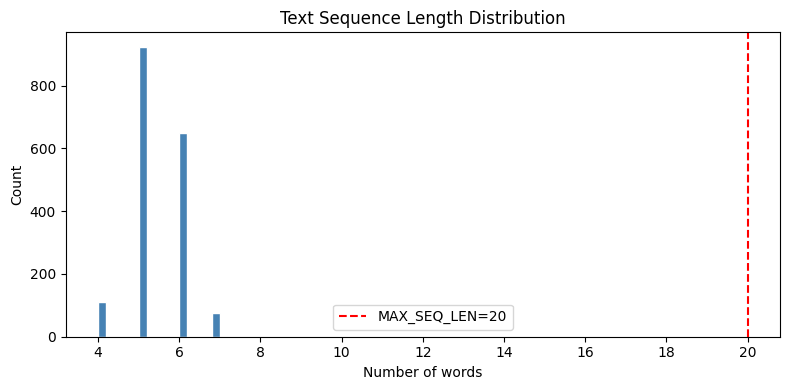

Max words in a text: 7
Mean words: 5.4
95th percentile: 6 words


In [8]:
lengths = train_df['text_clean'].apply(lambda x: len(x.split()))
plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=15, color='steelblue', edgecolor='white')
plt.title('Text Sequence Length Distribution')
plt.xlabel('Number of words')
plt.ylabel('Count')
plt.axvline(MAX_SEQ_LEN, color='red', linestyle='--', label=f'MAX_SEQ_LEN={MAX_SEQ_LEN}')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Max words in a text: {lengths.max()}')
print(f'Mean words: {lengths.mean():.1f}')
print(f'95th percentile: {lengths.quantile(0.95):.0f} words')

---
# 6. IMAGE Preprocessing

### 6.1 Image Config

In [9]:
IMG_SIZE    = (224, 224)   # EfficientNet / MobileNet standard
BATCH_SIZE  = 32

def load_and_preprocess_image(path: str) -> tf.Tensor:
    """
    تقرأ الصورة من الديسك، تعمل resize، وتعمل normalize لـ [0, 1].
    لو الصورة مش موجودة بتعمل tensor zeros بدلها.
    """
    full_path = os.path.join(IMAGE_DIR, path) if IMAGE_DIR else path
    try:
        img = tf.io.read_file(full_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = img / 255.0   # normalize to [0, 1]
    except Exception:
        img = tf.zeros([*IMG_SIZE, 3], dtype=tf.float32)
    return img

print(f'Image size: {IMG_SIZE}')
print(f'Batch size: {BATCH_SIZE}')

Image size: (224, 224)
Batch size: 32


### 6.2 Image Augmentation (Train only)

In [10]:
# Data augmentation للـ training بس
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
], name='data_augmentation')

print('Augmentation pipeline ready.')

Augmentation pipeline ready.


### 6.3 نشوف صور sample مع الـ augmentation

In [11]:
# =====================================================================
# شغّل الـ cell دي لو الصور موجودة على الجهاز
# =====================================================================
SHOW_IMAGES = False   # غيّر لـ True لو عندك الصور

if SHOW_IMAGES:
    sample_paths = train_df['image_path'].head(4).values
    fig, axes = plt.subplots(2, 4, figsize=(14, 6))

    for i, path in enumerate(sample_paths):
        img = load_and_preprocess_image(path)
        aug = data_augmentation(tf.expand_dims(img, 0))[0].numpy()

        axes[0, i].imshow(img.numpy())
        axes[0, i].set_title(f'Original\n{train_df["label"].iloc[i]}')
        axes[0, i].axis('off')

        axes[1, i].imshow(aug)
        axes[1, i].set_title('Augmented')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('SHOW_IMAGES=False — skip image display.')

SHOW_IMAGES=False — skip image display.


---
# 7. بناء tf.data Pipelines (Image + Text)

### 7.1 Image Description من الـ image_path (Fallback)
لو مش عندك الصور الفعلية دلوقتي، الـ description الموجود في `text_description` بيتستخدم.
لو عندك الصور، ممكن تولّد descriptions أوتوماتيك باستخدام نموذج زي BLIP — بنوضح ده في Section 9.

In [12]:
IMAGES_ON_DISK = False   # True لو الصور موجودة

def make_tf_dataset(df_split, augment=False, shuffle=False):
    """
    بيبني tf.data.Dataset يرجع dict:
      {'image': tensor [H,W,3], 'text': tensor [seq_len]}
    والـ label كـ one-hot tensor.
    """
    paths  = df_split['image_path'].values
    texts  = df_split['text_clean'].values
    labels = np.array(df_split['label_onehot'].tolist(), dtype=np.float32)

    def generator():
        for path, text, label in zip(paths, texts, labels):
            # --- Image ---
            if IMAGES_ON_DISK:
                img = load_and_preprocess_image(path)
            else:
                # placeholder zeros لو الصور مش موجودة
                img = tf.zeros([*IMG_SIZE, 3], dtype=tf.float32)

            # --- Text tokenization ---
            text_tok = text_vectorizer([text])[0]   # shape [MAX_SEQ_LEN]

            yield {'image': img, 'text': text_tok}, label

    output_sig = (
        {
            'image': tf.TensorSpec(shape=(*IMG_SIZE, 3), dtype=tf.float32),
            'text':  tf.TensorSpec(shape=(MAX_SEQ_LEN,), dtype=tf.int64),
        },
        tf.TensorSpec(shape=(NUM_CLASSES,), dtype=tf.float32),
    )

    ds = tf.data.Dataset.from_generator(generator, output_signature=output_sig)

    if shuffle:
        ds = ds.shuffle(buffer_size=1000, seed=42)

    if augment:
        ds = ds.map(
            lambda x, y: ({**x, 'image': data_augmentation(tf.expand_dims(x['image'], 0))[0]}, y),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_tf_dataset(train_df, augment=True,  shuffle=True)
val_ds   = make_tf_dataset(val_df,   augment=False, shuffle=False)
test_ds  = make_tf_dataset(test_df,  augment=False, shuffle=False)

print('Datasets built successfully!')
for batch_x, batch_y in train_ds.take(1):
    print('Image batch shape:', batch_x['image'].shape)
    print('Text  batch shape:', batch_x['text'].shape)
    print('Label batch shape:', batch_y.shape)

Datasets built successfully!
Image batch shape: (32, 224, 224, 3)
Text  batch shape: (32, 20)
Label batch shape: (32, 6)


---
# 8. EDA على الـ Text

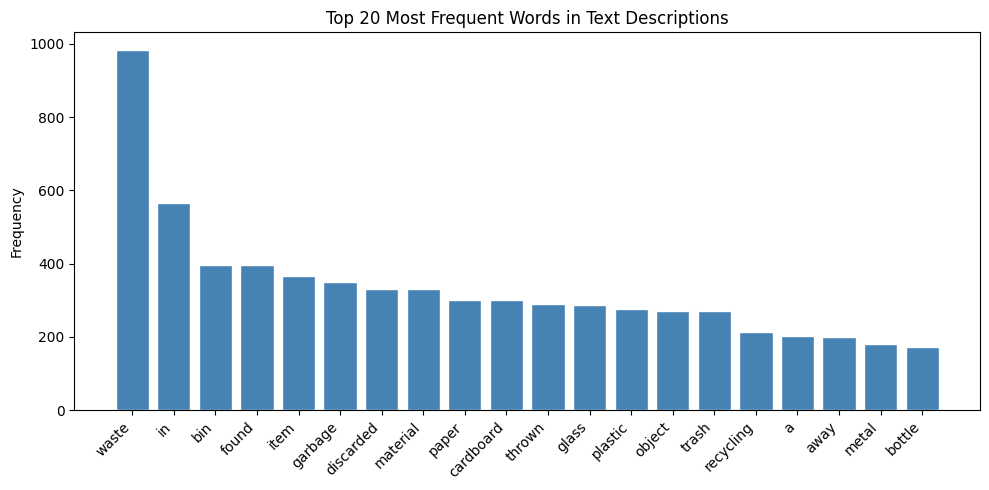

Total unique words: 58


In [13]:
from collections import Counter

all_words = ' '.join(train_df['text_clean']).split()
word_freq = Counter(all_words)

top_n = 20
words, counts = zip(*word_freq.most_common(top_n))

plt.figure(figsize=(10, 5))
plt.bar(words, counts, color='steelblue', edgecolor='white')
plt.title(f'Top {top_n} Most Frequent Words in Text Descriptions')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f'Total unique words: {len(word_freq)}')

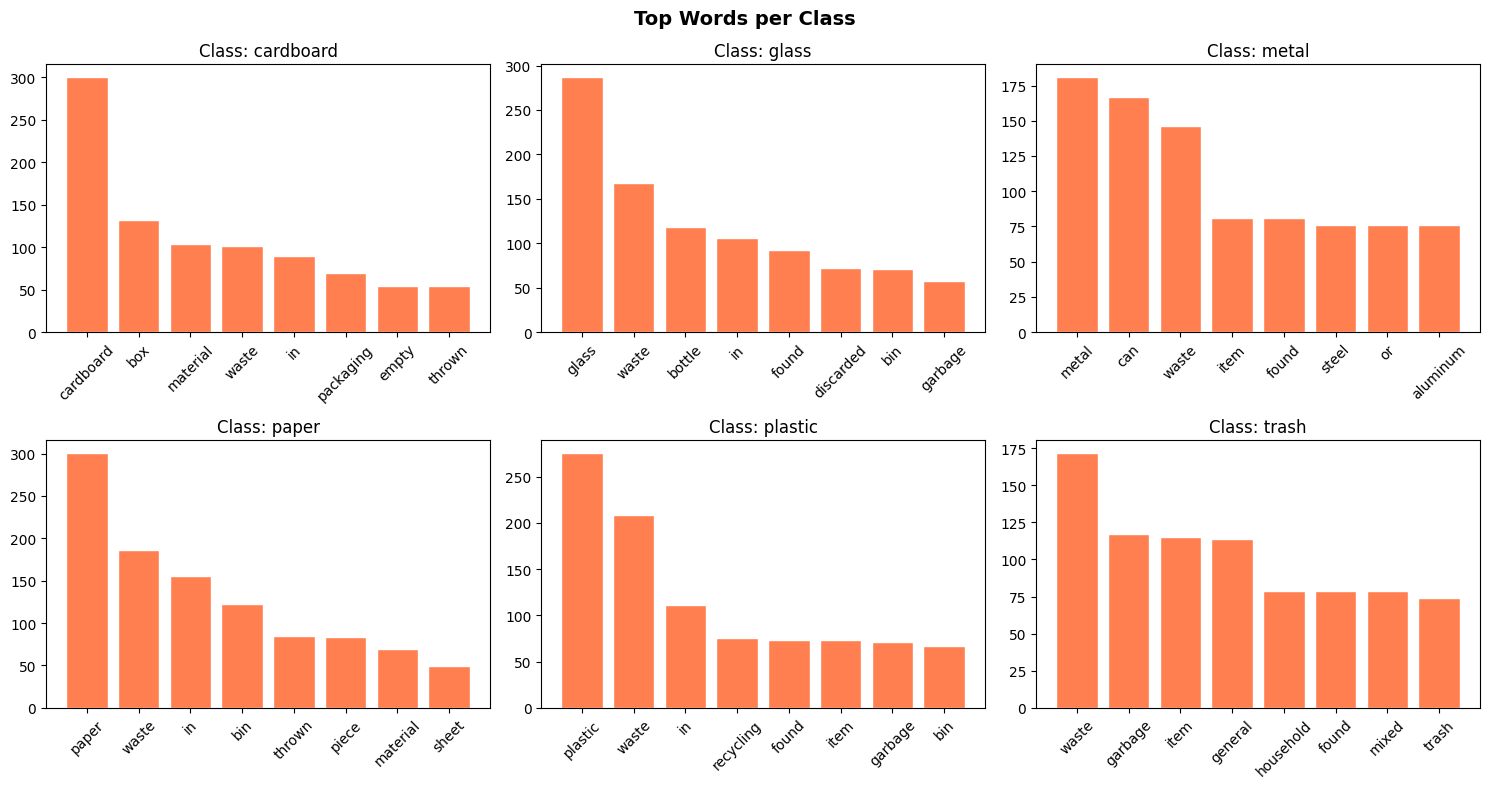

In [14]:
# نشوف الكلمات الأكتر شيوعاً لكل class
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, cls in enumerate(CLASS_NAMES):
    cls_texts = ' '.join(train_df[train_df['label'] == cls]['text_clean']).split()
    cls_freq  = Counter(cls_texts)
    words_cls, counts_cls = zip(*cls_freq.most_common(8))

    axes[idx].bar(words_cls, counts_cls, color='coral', edgecolor='white')
    axes[idx].set_title(f'Class: {cls}')
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Top Words per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 9. توليد Image Description (اختياري — لو عندك الصور)

لو عندك الصور الفعلية، ممكن تستخدم نموذج زي **BLIP** (Bootstrapped Language-Image Pretraining) علشان تولّد descriptions أوتوماتيك من الصور.

**ملاحظة:** الـ cell دي محتاج:
- `pip install transformers`
- الصور متوفرة على الجهاز
- GPU مستحسن (بطيء على CPU)

In [15]:
GENERATE_DESCRIPTIONS = False   # غيّر لـ True لو عندك الصور + transformers

if GENERATE_DESCRIPTIONS:
    from transformers import BlipProcessor, BlipForConditionalGeneration
    from PIL import Image

    print('Loading BLIP model...')
    blip_processor = BlipProcessor.from_pretrained('Salesforce/blip-image-captioning-base')
    blip_model     = BlipForConditionalGeneration.from_pretrained('Salesforce/blip-image-captioning-base')

    def generate_caption(image_path: str) -> str:
        try:
            full_path = os.path.join(IMAGE_DIR, image_path) if IMAGE_DIR else image_path
            img = Image.open(full_path).convert('RGB')
            inputs = blip_processor(img, return_tensors='pt')
            out = blip_model.generate(**inputs, max_new_tokens=30)
            caption = blip_processor.decode(out[0], skip_special_tokens=True)
            return caption
        except Exception as e:
            return ''

    # نولّد descriptions لأول 5 صور كـ demo
    sample = train_df.head(5).copy()
    sample['generated_caption'] = sample['image_path'].apply(generate_caption)
    print(sample[['image_path', 'text_description', 'generated_caption', 'label']])

    # لو عايز تولّد للكل:
    # df['generated_caption'] = df['image_path'].apply(generate_caption)
    # df.to_csv('dataset_with_captions.csv', index=False)
else:
    print('GENERATE_DESCRIPTIONS=False — skip BLIP generation.')
    print('لو عندك الصور: غيّر GENERATE_DESCRIPTIONS = True')

GENERATE_DESCRIPTIONS=False — skip BLIP generation.
لو عندك الصور: غيّر GENERATE_DESCRIPTIONS = True


---
# 10. تصدير الـ Preprocessed Data

In [16]:
# نحفظ الـ splits كـ CSV
train_df[['image_path', 'text_clean', 'label', 'label_encoded']].to_csv('train_split.csv', index=False)
val_df[['image_path', 'text_clean', 'label', 'label_encoded']].to_csv('val_split.csv', index=False)
test_df[['image_path', 'text_clean', 'label', 'label_encoded']].to_csv('test_split.csv', index=False)

print('Saved: train_split.csv, val_split.csv, test_split.csv')
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Saved: train_split.csv, val_split.csv, test_split.csv
Train: 1760 | Val: 377 | Test: 378


In [17]:
# نحفظ الـ TextVectorization vocab
vocab = text_vectorizer.get_vocabulary()
with open('vocab.txt', 'w') as f:
    for word in vocab:
        f.write(word + '\n')

print(f'Saved vocab.txt with {len(vocab)} tokens')

Saved vocab.txt with 60 tokens


---
# 11. ملخص الـ Preprocessing Pipeline

| Step | What happens |
|------|---------------|
| **Load CSV** | `pandas.read_csv` — تصحيح `\\` في الـ paths |
| **Label Encoding** | `LabelEncoder` → integers → one-hot |
| **Train/Val/Test Split** | 70% / 15% / 15% stratified |
| **Text Cleaning** | lowercase, remove punctuation, strip whitespace |
| **Text Tokenization** | `TextVectorization` — vocab=5000, seq_len=20 |
| **Image Preprocessing** | resize 224×224, normalize [0,1] |
| **Image Augmentation** | flip, rotate, zoom, brightness, contrast (train only) |
| **tf.data Pipeline** | generator → batch → prefetch — returns `{image, text}` dict |
| **Image Captioning** | BLIP (اختياري) لتوليد text descriptions من الصور |

---
# 12. الخطوة الجاية — بناء الـ Multimodal Model

الـ preprocessing خلصت! الـ dataset جاهز للـ training. الـ multimodal model هيكون شكله كده:

```
Image Branch:
  EfficientNetB0 (pretrained) → GlobalAveragePooling → Dense(256)

Text Branch:
  Embedding(vocab_size, 128) → LSTM(128) أو GlobalAveragePooling

Fusion:
  Concatenate([image_feat, text_feat]) → Dense(256) → Dense(NUM_CLASSES, softmax)
```

الـ `train_ds` / `val_ds` / `test_ds` جاهزين للاستخدام مباشرةً في `model.fit(train_ds, validation_data=val_ds)`.